### Análise Exploratória dos Dados

Esse notebook tem por objetivo fazer a análise exploratória dos dados da base organizada da PNAD Contínua para os anos de 2019-2025.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

#### Carregamento da base

In [45]:
df = pd.read_csv("../data/PNAD_empilhada.csv")

df.head()

,Ano,Trimestre,UF,V1028,V2007,V2009,V2010,V3009A,V3014,V4001,V4010,V4012,V4013,V4028,V4029,V403312,V4039,V4040,V4071
0,2019,1,26,259.050135,1,35,4,7.0,1.0,1.0,8153.0,6.0,14001.0,NaN,NaN,2000.0,44.0,3.0,NaN
1,2019,1,26,259.050135,2,31,1,12.0,1.0,1.0,8153.0,6.0,14001.0,NaN,NaN,2000.0,44.0,3.0,NaN
2,2019,1,26,259.050135,1,10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,26,287.125126,1,57,4,5.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
4,2019,1,26,287.125126,2,22,4,7.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [46]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 530602 entries, 0 to 530601
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Ano        530602 non-null  int64  
 1   Trimestre  530602 non-null  int64  
 2   UF         530602 non-null  int64  
 3   V1028      530602 non-null  float64
 4   V2007      530602 non-null  int64  
 5   V2009      530602 non-null  int64  
 6   V2010      530602 non-null  int64  
 7   V3009A     339465 non-null  float64
 8   V3014      328497 non-null  float64
 9   V4001      432064 non-null  float64
 10  V4010      184914 non-null  float64
 11  V4012      184914 non-null  float64
 12  V4013      184914 non-null  float64
 13  V4028      16357 non-null   float64
 14  V4029      102753 non-null  float64
 15  V403312    177983 non-null  float64
 16  V4039      184914 non-null  float64
 17  V4040      184914 non-null  float64
 18  V4071      247150 non-null  float64
dtypes: float64(13), int64(6)
memory us

,Ano,Trimestre,UF,V1028,V2007,V2009,V2010,V3009A,V3014,V4001,V4010,V4012,V4013,V4028,V4029,V403312,V4039,V4040,V4071
count,530602.000000,530602.000000,530602.0,530602.000000,530602.000000,530602.000000,530602.000000,339465.000000,328497.000000,432064.000000,184914.000000,184914.000000,184914.000000,16357.000000,102753.000000,177983.000000,184914.000000,184914.000000,247150.000000
mean,2022.003025,2.501027,26.0,497.434156,1.525226,36.361644,2.899222,8.637300,1.445730,1.624512,5984.161691,4.080756,51616.873017,1.204255,1.467266,1878.445537,37.795435,3.446862,1.873097
std,2.039581,1.120755,0.0,367.955703,0.499364,22.046121,1.394460,2.365201,0.497047,0.484249,2348.884010,1.577956,31503.450397,0.403169,0.498930,3138.826061,12.489779,0.903619,0.332865
min,2019.000000,1.000000,26.0,13.668183,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000
25%,2020.000000,1.000000,26.0,267.813601,1.000000,18.000000,1.000000,7.000000,1.000000,1.000000,4229.000000,3.000000,31000.000000,1.000000,1.000000,700.000000,30.000000,3.000000,2.000000
50%,2022.000000,3.000000,26.0,441.642067,2.000000,35.000000,4.000000,10.000000,1.000000,2.000000,6111.000000,3.000000,48080.000000,1.000000,1.000000,1212.000000,40.000000,4.000000,2.000000
75%,2024.000000,4.000000,26.0,638.035340,2.000000,53.000000,4.000000,10.000000,2.000000,2.000000,8182.000000,6.000000,84013.000000,1.000000,2.000000,1900.000000,44.000000,4.000000,2.000000
max,2025.000000,4.000000,26.0,33788.162620,2.000000,113.000000,9.000000,15.000000,2.000000,2.000000,9629.000000,7.000000,99000.000000,2.000000,2.000000,200000.000000,120.000000,4.000000,2.000000


Inicialmente, foi realizado o carregamento da base de dados consolidada da PNAD Contínua referente ao período de 2019 a 2025. Em seguida, foram utilizadas funções de inspeção para obter uma visão geral da estrutura do conjunto de dados.

A base é composta por 530.602 registros e 19 variáveis, contendo informações demográficas, educacionais e relacionadas ao mercado de trabalho. As variáveis encontram-se armazenadas em formato numérico, sendo classificadas entre os tipos inteiros (int64) e reais (float64).

A análise da estrutura da base evidenciou a presença de diferentes quantidades de valores não preenchidos em algumas variáveis. Entretanto, esses valores não representam necessariamente dados faltantes, mas, em muitos casos, situações em que a pergunta correspondente não se aplicava ao indivíduo entrevistado.

As estatísticas descritivas permitiram identificar características gerais da população analisada. Observou-se que os registros estão distribuídos entre os anos de 2019 e 2025 e abrangem os quatro trimestres de cada ano. A idade dos indivíduos varia entre 0 e 113 anos, com mediana de 35 anos. Em relação ao rendimento mensal, os valores apresentam elevada dispersão, variando de R$ 4,00 a R$ 200.000,00, o que indica a existência de grande heterogeneidade na distribuição da renda. As horas trabalhadas por semana apresentam mediana de 40 horas, valor compatível com a jornada semanal tradicional de trabalho.

#### Valores ausentes

In [47]:
df.isnull().sum().sort_values(ascending=False)

V4028        514245
V4029        427849
V403312      352619
V4013        345688
V4040        345688
V4039        345688
V4010        345688
V4012        345688
V4071        283452
V3014        202105
V3009A       191137
V4001         98538
UF                0
Ano               0
Trimestre         0
V1028             0
V2007             0
V2009             0
V2010             0
dtype: int64

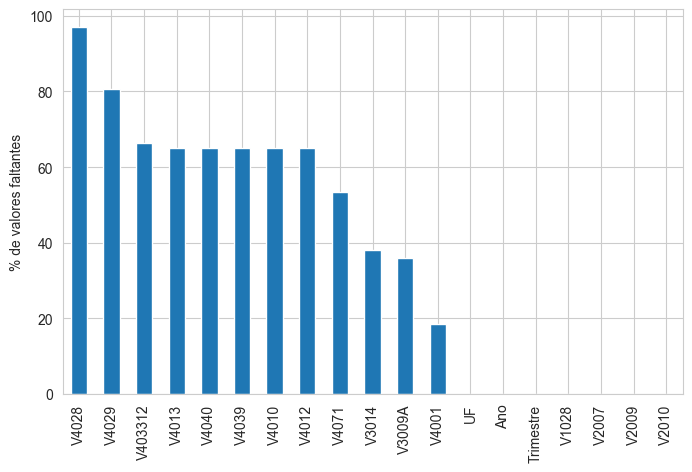

In [48]:
(df.isnull().mean()*100).sort_values(ascending=False).plot.bar()
plt.ylabel("% de valores faltantes")
plt.show()

Em seguida, foi realizada uma análise da quantidade de valores ausentes presentes em cada variável da base de dados. Para isso, foi contabilizado o número de registros não preenchidos em cada coluna, permitindo identificar quais informações apresentam maior incidência de valores ausentes.

Observou-se que algumas variáveis relacionadas ao mercado de trabalho, como servidor público, carteira assinada, rendimento mensal, horas trabalhadas, atividade econômica e tempo no trabalho, apresentam uma quantidade expressiva de valores não preenchidos. Da mesma forma, variáveis relacionadas ao nível educacional e à conclusão do curso também apresentam registros ausentes.

Entretanto, esses valores não representam necessariamente falhas ou perdas na coleta dos dados. Em grande parte dos casos, tratam-se de situações em que a pergunta correspondente não era aplicável ao indivíduo entrevistado. Por exemplo, informações sobre rendimento e jornada de trabalho não se aplicam a pessoas que não estavam ocupadas no momento da pesquisa, assim como determinadas questões educacionais podem não ser pertinentes para indivíduos que não frequentavam cursos ou que ainda não haviam alcançado determinados níveis de escolaridade.

Por outro lado, variáveis básicas de identificação e características demográficas, como ano da pesquisa, trimestre, peso amostral, sexo, idade e cor ou raça, encontram-se integralmente preenchidas, não apresentando valores ausentes.

A identificação desse padrão é muito para orientar as etapas posteriores de tratamento dos dados, permitindo distinguir situações de não aplicabilidade de eventuais problemas de qualidade da informação.

#### Renomeando colunas

In [49]:
df = df.rename(columns={
    "V1028": "peso",
    "V2007": "sexo",
    "V2009": "idade",
    "V2010": "cor_raca",
    "V3009A": "nivel_educacional",
    "V3014": "curso_concluido",
    "V4001": "trabalhou_ou_estagiou",
    "V4010": "cargo",
    "V4012": "tipo_trabalho",
    "V4013": "atividade",
    "V4028": "servidor_publico",
    "V4029": "carteira_assinada",
    "V403312": "renda_mensal",
    "V4039": "horas_semana",
    "V4040": "tempo_trabalho",
    "V4071": "procurou_emprego"
})

Após a inspeção inicial da base de dados, foi realizada a renomeação das variáveis selecionadas da PNAD Contínua. Os nomes originais das colunas, representados por códigos utilizados pelo IBGE, foram substituídos por denominações mais descritivas, relacionadas ao significado de cada informação.

Essa etapa não altera os valores presentes na base de dados, mas tem como finalidade tornar o conjunto de dados mais legível e facilitar a interpretação dos resultados ao longo da análise exploratória. Dessa forma, variáveis como sexo, idade, cor ou raça, nível educacional, renda, horas trabalhadas e características da ocupação passaram a ser identificadas por nomes mais intuitivos, reduzindo a necessidade de consultas constantes ao dicionário de dados da pesquisa.

O objetivo foi aumentar a clareza do código e a compreensão das análises desenvolvidas nas etapas subsequentes

#### Tratamento de Valores Não Aplicáveis

In [50]:
colunas = [
    "nivel_educacional",
    "curso_concluido",
    "trabalhou_ou_estagiou",
    "cargo",
    "tipo_trabalho",
    "atividade",
    "servidor_publico",
    "carteira_assinada",
    "tempo_trabalho",
    "procurou_emprego"
]

df[colunas] = df[colunas].fillna(999)

In [51]:
df.isnull().sum().sort_values(ascending=False)

renda_mensal             352619
horas_semana             345688
Ano                           0
UF                            0
Trimestre                     0
peso                          0
sexo                          0
nivel_educacional             0
curso_concluido               0
idade                         0
cor_raca                      0
cargo                         0
trabalhou_ou_estagiou         0
tipo_trabalho                 0
atividade                     0
carteira_assinada             0
servidor_publico              0
tempo_trabalho                0
procurou_emprego              0
dtype: int64

Durante a inspeção da base de dados, observou-se a presença de diversos valores ausentes (NaN) em algumas variáveis. No entanto, esses valores não representam dados faltantes decorrentes de erros de coleta ou inconsistências, mas sim situações em que a pergunta correspondente não se aplicava ao indivíduo entrevistado.

Para preservar essa informação e evitar a perda de registros nas análises subsequentes, os valores NaN foram substituídos por um código específico, posteriormente associado à categoria "Não aplicável". Essa abordagem permite manter a consistência da base e garantir que todas as observações sejam consideradas nas análises exploratórias e estatísticas.

As variáveis de renda e horas_semanas não receberam o tratamento, pois seus valores correspondem a valores numéricos, e não categóricos. Sendo assim, permaneceram com NaN.

#### Correlação entre variáveis numéricas

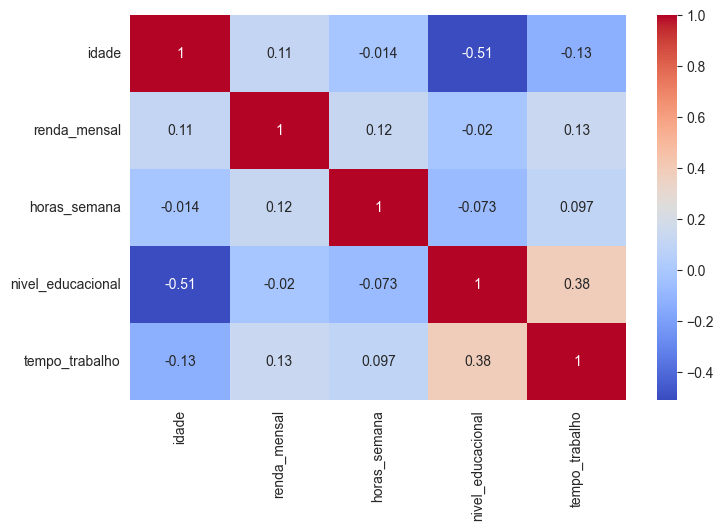

In [52]:
variaveis = [
    "idade",
    "renda_mensal",
    "horas_semana",
    "nivel_educacional",
    "tempo_trabalho"
]

corr = df[variaveis].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Com o intuito de investigar possíveis relações entre as variáveis quantitativas presentes na base, foi calculada a matriz de correlação entre idade, renda, horas trabalhadas por semana, nível educacional e tempo de trabalho. Os coeficientes de correlação variam entre -1 e 1, sendo que valores próximos de 1 indicam uma relação positiva forte, valores próximos de -1 indicam uma relação negativa forte e valores próximos de zero sugerem ausência de associação linear significativa.

De modo geral, observam-se correlações de baixa intensidade entre a maior parte das variáveis analisadas. A renda apresenta correlação positiva, porém fraca, com as horas trabalhadas por semana (0,12), com a idade (0,11) e com o tempo de trabalho (0,13), indicando que indivíduos mais experientes ou que trabalham mais horas tendem a apresentar rendimentos ligeiramente superiores.

Destaca-se a correlação negativa moderada entre idade e nível educacional (-0,51), sugerindo que os indivíduos mais jovens tendem a possuir níveis educacionais mais elevados em comparação aos mais idosos. Esse resultado pode refletir o aumento do acesso à educação ao longo das últimas décadas.

Também foi observada uma correlação positiva moderada entre nível educacional e tempo de trabalho (0,38), indicando uma associação entre maior escolaridade e maior permanência no trabalho. Entretanto, é importante ressaltar que a correlação não implica causalidade, representando apenas uma medida da intensidade da associação linear entre as variáveis analisadas.

De maneira geral, os resultados indicam que as variáveis estudadas apresentam relações relativamente fracas, evidenciando que o comportamento da renda e das demais características analisadas é influenciado por diversos fatores não contemplados diretamente nesta matriz de correlação.

#### Distribuição por sexo

In [53]:
df["sexo"] = df["sexo"].map({
    1: "Homem",
    2: "Mulher",
})

In [54]:
df["sexo"].value_counts(dropna=False)

sexo
Mulher    278686
Homem     251916
Name: count, dtype: int64

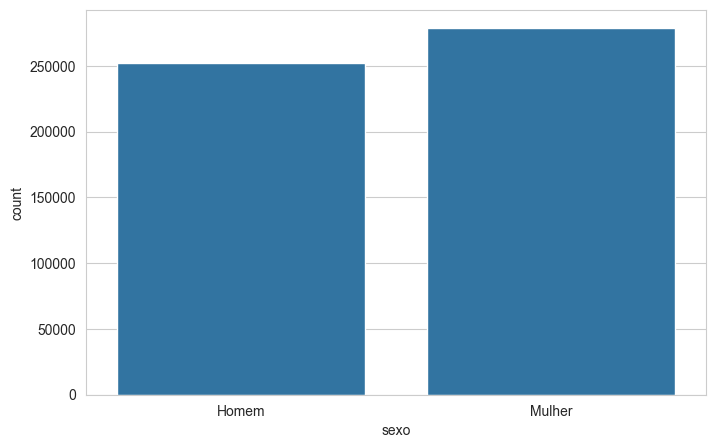

In [55]:
sns.countplot(data=df, x="sexo")
plt.show()

A variável referente ao sexo dos indivíduos foi convertida dos códigos numéricos originais para categorias descritivas, permitindo uma interpretação mais intuitiva dos resultados. Em seguida, foi realizada a contagem do número de registros pertencentes a cada categoria.

Observa-se uma distribuição relativamente equilibrada entre homens e mulheres na base de dados analisada. Do total de 530.602 indivíduos, 278.686 correspondem ao sexo feminino e 251.916 ao sexo masculino.

Os resultados indicam uma ligeira predominância de mulheres na amostra, representando aproximadamente 52,5% dos registros, enquanto os homens correspondem a cerca de 47,5%. Essa distribuição sugere que a composição da população analisada apresenta uma participação semelhante entre os dois grupos, sem diferenças expressivas em termos de quantidade de indivíduos.

#### Distribuição por idade

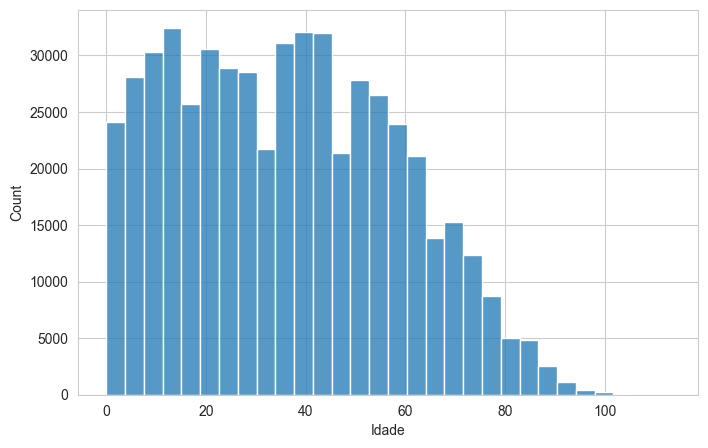

In [56]:
sns.histplot(df["idade"], bins=30)
plt.xlabel("Idade")
plt.show()

In [57]:
df["idade"].describe()

count    530602.000000
mean         36.361644
std          22.046121
min           0.000000
25%          18.000000
50%          35.000000
75%          53.000000
max         113.000000
Name: idade, dtype: float64

Inicialmente, foi construído um histograma para visualizar a distribuição das idades na amostra. O gráfico evidencia uma concentração mais elevada de indivíduos nas faixas etárias entre aproximadamente 10 e 60 anos, correspondendo principalmente à população em idade ativa. A frequência de registros diminui gradativamente nas idades mais avançadas, sendo observada uma quantidade relativamente pequena de indivíduos com mais de 80 anos.

Em seguida, foram obtidas estatísticas descritivas da variável idade, permitindo caracterizar a composição etária da população analisada. Observa-se que a base contém indivíduos com idades variando entre 0 e 113 anos, com idade média de aproximadamente 36 anos e mediana de 35 anos. Os quartis indicam que 25% dos indivíduos possuem até 18 anos, enquanto 75% possuem até 53 anos.

A distribuição obtida é compatível com a estrutura demográfica da população brasileira, apresentando predominância de indivíduos em idade economicamente ativa e menor participação relativa das faixas etárias mais elevadas.

#### Cor ou raça

In [58]:
df["cor_raca"] = df["cor_raca"].map({
    1: "Branca",
    2: "Preta",
    3: "Amarela",
    4: "Parda",
    5: "Indígena",
    9: "Ignorado"
})

In [59]:
df["cor_raca"].value_counts(dropna=False)

cor_raca
Parda       316789
Branca      166498
Preta        42552
Indígena      2487
Amarela       2224
Ignorado        52
Name: count, dtype: int64

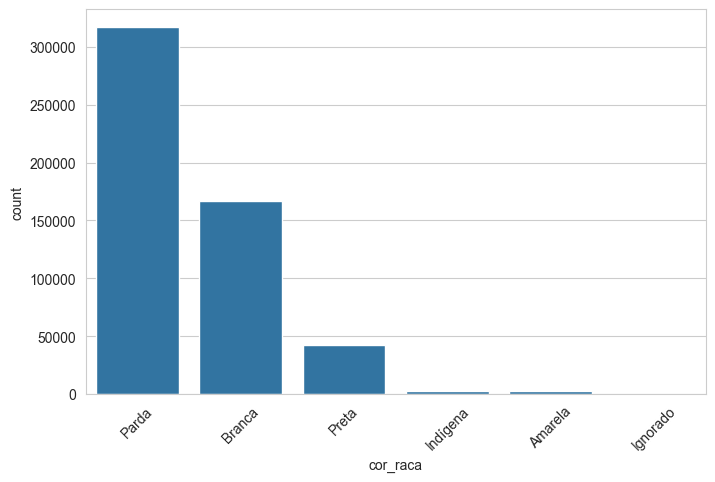

In [60]:
sns.countplot(
    data=df,
    x="cor_raca"
)
plt.xticks(rotation=45)
plt.show()

A variável referente à cor ou raça dos indivíduos foi convertida dos códigos numéricos para categorias descritivas, permitindo uma interpretação mais clara da composição da população analisada. Posteriormente, foi realizada a contagem da quantidade de registros em cada categoria.

Observa-se que a categoria mais frequente é a de indivíduos que se autodeclaram pardos, totalizando 316.789 registros, seguida pela categoria de indivíduos brancos, com 166.498 registros. Os indivíduos autodeclarados pretos correspondem a 42.552 registros, enquanto as categorias indígena e amarela apresentam menor representatividade, com 2.487 e 2.224 registros, respectivamente. A categoria "Ignorado" representa uma parcela muito reduzida da amostra, com apenas 52 registros.

De forma geral, os resultados evidenciam a predominância de indivíduos autodeclarados pardos na população analisada, seguida pelos indivíduos brancos. Essa distribuição é compatível com a composição demográfica observada no Brasil e reflete a diversidade étnico-racial presente na população.

#### Escolaridade

In [61]:
mapa_escolaridade = {
    1: "Creche",
    2: "Pré-escola",
    3: "Classe de alfabetização (CA)",
    4: "Alfabetização de jovens e adultos",
    5: "Antigo primário (elementar)",
    6: "Antigo ginásio (médio 1º ciclo)",
    7: "Ensino fundamental regular",
    8: "EJA ou supletivo do 1º grau",
    9: "Antigo científico, clássico etc. (médio 2º ciclo)",
    10: "Ensino médio regular",
    11: "EJA ou supletivo do 2º grau",
    12: "Superior - graduação",
    13: "Especialização",
    14: "Mestrado",
    15: "Doutorado",
    999: "Não Aplicável"
}

df["nivel_educacional"] = df["nivel_educacional"].map(mapa_escolaridade)

In [62]:
df["nivel_educacional"].value_counts(dropna=False)

nivel_educacional
Não Aplicável                                        191137
Ensino médio regular                                 127351
Ensino fundamental regular                           116177
Superior - graduação                                  35028
Antigo primário (elementar)                           27285
Especialização                                         9833
Classe de alfabetização (CA)                           7490
EJA ou supletivo do 2º grau                            3359
Antigo científico, clássico etc. (médio 2º ciclo)      3121
Antigo ginásio (médio 1º ciclo)                        3112
EJA ou supletivo do 1º grau                            2769
Mestrado                                               1263
Alfabetização de jovens e adultos                      1136
Pré-escola                                              979
Doutorado                                               546
Creche                                                   16
Name: count, dtype: in

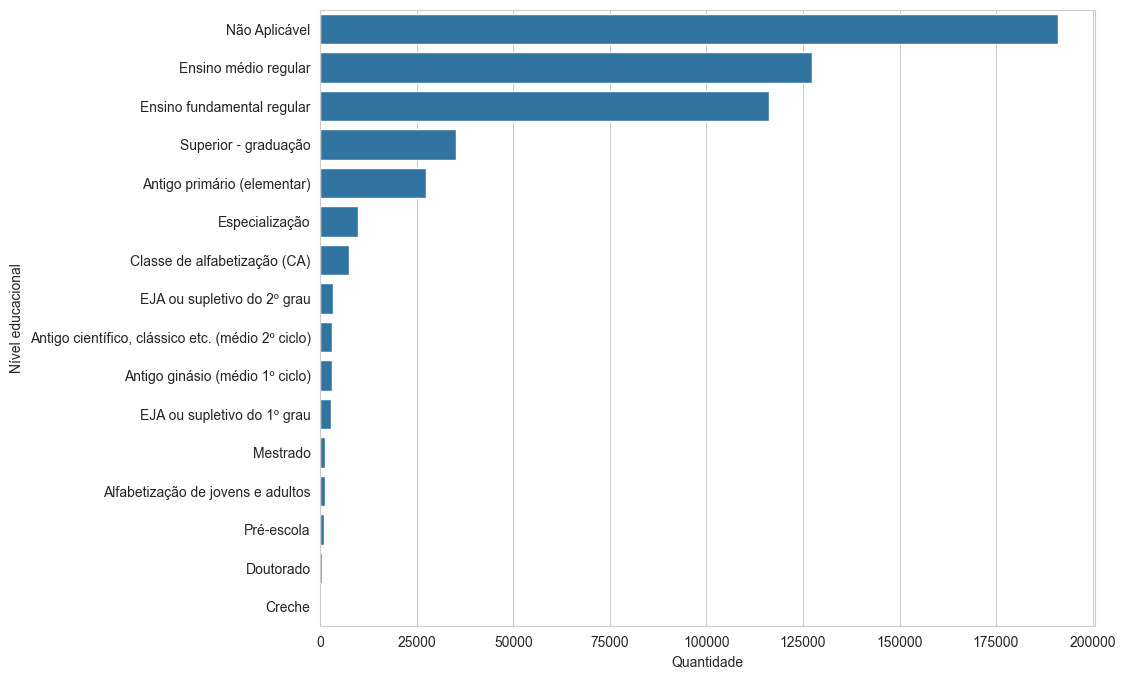

In [63]:
plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    y="nivel_educacional",
    order=df["nivel_educacional"].value_counts(dropna=False).index
)

plt.xlabel("count")
plt.ylabel("Nível educacional")
plt.show()

A variável referente ao nível educacional foi convertida dos códigos numéricos utilizados pela PNAD Contínua para categorias textuais mais descritivas, permitindo uma interpretação mais clara dos resultados. Os casos em que a variável não era aplicável ao indivíduo foram agrupados na categoria "Não Aplicável".

A análise da frequência das categorias mostra que uma parcela significativa dos registros pertence à categoria "Não Aplicável", o que está associado principalmente aos indivíduos para os quais a informação sobre escolaridade não se aplicava. Entre os níveis educacionais efetivamente observados, destacam-se o ensino médio regular, com 127.351 registros, e o ensino fundamental regular, com 116.177 registros, constituindo as categorias mais representativas da base.

Observa-se também a presença de 35.028 indivíduos com formação superior em nível de graduação e 9.833 indivíduos com especialização. Os níveis de mestrado e doutorado apresentam menor frequência, com 1.263 e 546 registros, respectivamente. As categorias relacionadas a modalidades de ensino mais antigas ou específicas, como classes de alfabetização, supletivos e ensino primário, possuem participação relativamente reduzida.

De maneira geral, os resultados indicam uma predominância de indivíduos com ensino fundamental e ensino médio, enquanto os níveis mais elevados de escolaridade representam uma parcela menor da população analisada. Essa distribuição é compatível com a estrutura educacional observada na população brasileira e fornece subsídios importantes para análises posteriores envolvendo renda, mercado de trabalho e desigualdades socioeconômicas.

#### Pessoas que trabalham

In [64]:
df["trabalhou_ou_estagiou"] = df["trabalhou_ou_estagiou"].map({
    1: "Sim",
    2: "Não",
    999: "Não Aplicável"
})

In [65]:
df["trabalhou_ou_estagiou"].value_counts(dropna=False)

trabalhou_ou_estagiou
Não              269829
Sim              162235
Não Aplicável     98538
Name: count, dtype: int64

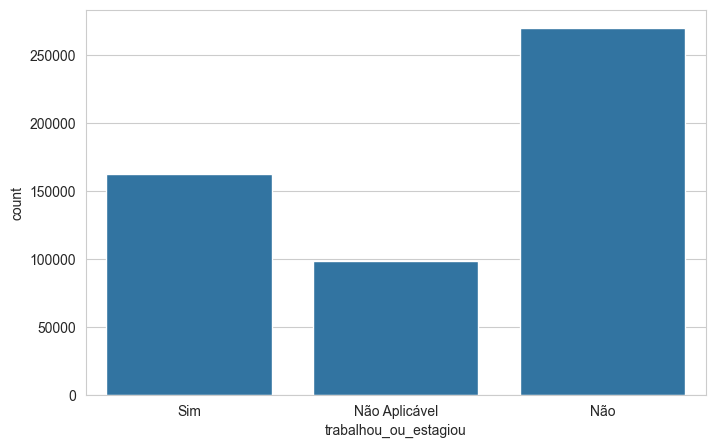

In [66]:
sns.countplot(data=df, x="trabalhou_ou_estagiou")
plt.show()

A variável referente à condição de ocupação foi convertida dos códigos numéricos da PNAD Contínua para categorias descritivas, permitindo identificar se o indivíduo exerceu algum trabalho ou estágio remunerado por pelo menos uma hora durante o período de referência da pesquisa.

Os resultados mostram que a maior parcela dos indivíduos analisados não estava ocupada, totalizando 269.829 registros. Por outro lado, 162.235 indivíduos declararam ter exercido alguma atividade remunerada no período considerado. Além disso, 98.538 registros foram classificados como "Não Aplicável", correspondendo a situações em que a pergunta não se aplicava ao entrevistado.

A distribuição observada evidencia que a população presente na base não é composta exclusivamente por pessoas economicamente ativas, incluindo também indivíduos fora da força de trabalho ou para os quais determinadas questões relacionadas ao emprego não eram pertinentes. Essa característica é consistente com o escopo da PNAD Contínua, que busca representar diferentes perfis da população brasileira.

A identificação da condição de ocupação é muito importante para as análises subsequentes, uma vez que diversas variáveis relacionadas ao mercado de trabalho, como renda, jornada semanal, tipo de ocupação e tempo no emprego, estão diretamente associadas à existência de uma atividade remunerada.

#### Tipo de ocupação

In [67]:
mapa_trabalho = {
    1: "Trabalhador doméstico",
    2: "Militar",
    3: "CLT",
    4: "Concursado",
    5: "Empregador",
    6: "Conta própria",
    7: "Familiar não remunerado",
    999: "Não Aplicável"
}

df["tipo_trabalho"] = df["tipo_trabalho"].map(mapa_trabalho)

In [68]:
df["tipo_trabalho"].value_counts(dropna=False)

tipo_trabalho
Não Aplicável              345688
CLT                         81999
Conta própria               56899
Concursado                  22689
Trabalhador doméstico       11081
Empregador                   6258
Familiar não remunerado      4419
Militar                      1569
Name: count, dtype: int64

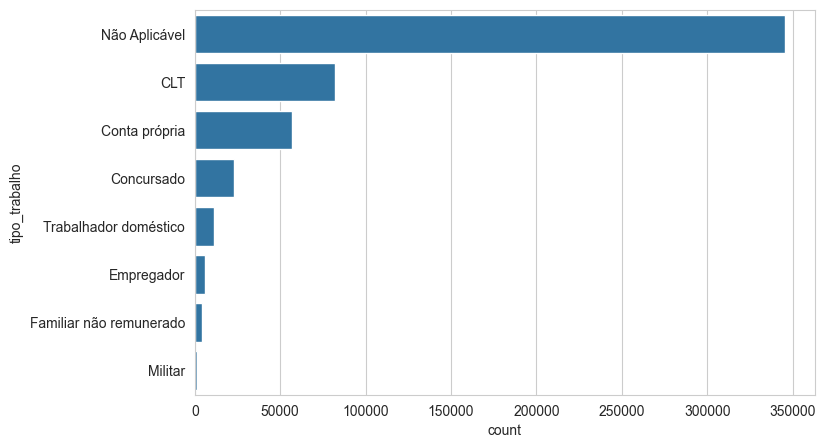

In [69]:
sns.countplot(
    data=df,
    y="tipo_trabalho",
    order=df["tipo_trabalho"].value_counts(dropna=False).index
)
plt.show()

A variável referente ao tipo de ocupação foi convertida dos códigos numéricos para categorias textuais, permitindo identificar a forma de inserção dos indivíduos no mercado de trabalho. Os registros em que a variável não se aplicava foram agrupados na categoria "Não Aplicável".

Observa-se que a categoria "Não Aplicável" apresenta a maior frequência, com 345.688 registros, refletindo principalmente indivíduos que não exerciam atividade ocupacional no período de referência ou para os quais a questão não era pertinente.

Entre os indivíduos ocupados, a categoria mais frequente corresponde aos trabalhadores com vínculo formal regido pela Consolidação das Leis do Trabalho (CLT), totalizando 81.999 registros. Em seguida, destacam-se os trabalhadores por conta própria, com 56.899 registros, e os servidores públicos concursados, com 22.689 registros.

As categorias trabalhador doméstico, empregador, trabalhador familiar não remunerado e militar apresentam menor participação relativa na amostra, totalizando 11.081, 6.258, 4.419 e 1.569 registros, respectivamente.

De maneira geral, os resultados indicam que os vínculos formais de trabalho e as atividades por conta própria representam as formas predominantes de inserção ocupacional entre os indivíduos economicamente ativos da base analisada. Essa distribuição é importante para dar uma visão inicial da estrutura do mercado de trabalho e possibilitar análises posteriores envolvendo renda, escolaridade e características da ocupação.

#### Distribuição da renda

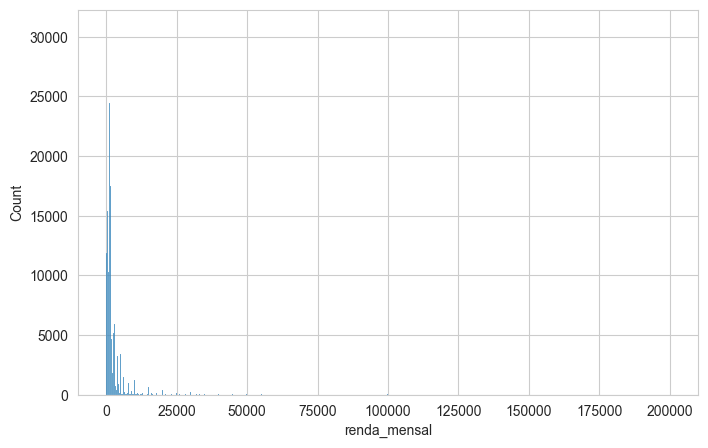

In [70]:
sns.histplot(data=df, x="renda_mensal")
plt.show()

In [71]:
df["renda_mensal"].describe()

count    177983.000000
mean       1878.445537
std        3138.826061
min           4.000000
25%         700.000000
50%        1212.000000
75%        1900.000000
max      200000.000000
Name: renda_mensal, dtype: float64

Foram obtidas estatísticas descritivas da variável renda, permitindo caracterizar o comportamento dos rendimentos mensais dos indivíduos que possuíam essa informação disponível. Observa-se que a renda apresenta média de aproximadamente R$1.878,45 e mediana de R$1.212,00, indicando uma diferença considerável entre essas medidas. Essa discrepância sugere a existência de uma distribuição assimétrica, influenciada pela presença de indivíduos com rendimentos elevados.

Os quartis indicam que 25% dos indivíduos possuem renda de até R$700,00, enquanto 75% apresentam rendimentos de até R$1.900,00. Por outro lado, o valor máximo registrado é de R$ 200.000,00, evidenciando a existência de observações extremas que contribuem para aumentar significativamente a média da distribuição.

O histograma reforça essa característica ao mostrar uma forte concentração de indivíduos nas faixas de renda mais baixas e uma redução gradual da frequência à medida que os rendimentos aumentam. A presença de poucos indivíduos com rendas muito elevadas produz uma cauda longa à direita, característica típica de distribuições de renda observadas em populações reais.

De maneira geral, os resultados evidenciam uma distribuição bastante desigual dos rendimentos, com predominância de indivíduos concentrados nas faixas de renda mais baixas e uma pequena parcela da população apresentando rendimentos substancialmente superiores aos demais. 

#### Renda por escolaridade

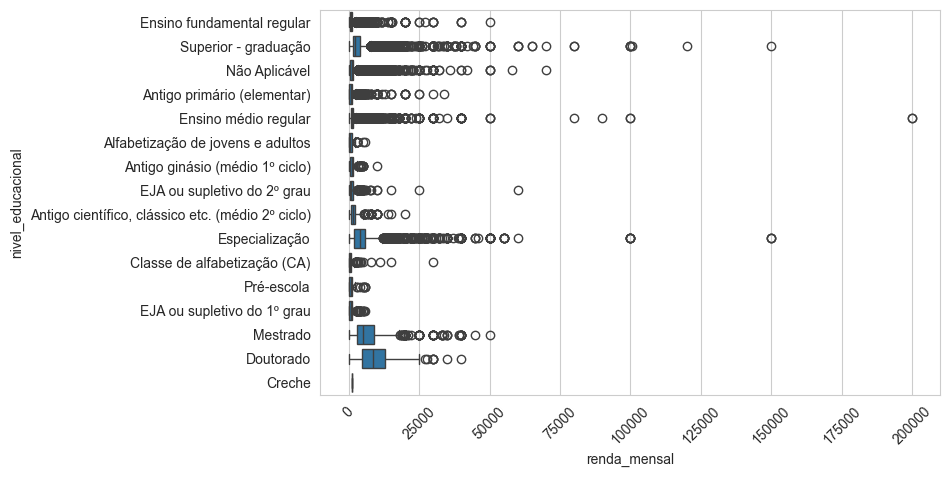

In [72]:
sns.boxplot(
    data=df,
    y="nivel_educacional",
    x="renda_mensal"
)

plt.xticks(rotation=45)
plt.show()

Com o objetivo de investigar a relação entre escolaridade e rendimento, foi construído um boxplot da variável renda para cada nível educacional presente na base. Esse tipo de gráfico permite comparar a distribuição dos rendimentos entre os grupos, evidenciando medidas de posição, dispersão e a ocorrência de valores extremos.

De maneira geral, observa-se uma tendência de aumento dos rendimentos à medida que o nível educacional se eleva. Indivíduos com formação em nível de pós-graduação, especialmente aqueles com mestrado e doutorado, apresentam medianas de renda superiores às observadas nos demais grupos. Em contrapartida, os menores rendimentos concentram-se entre indivíduos com níveis de escolaridade mais baixos, como ensino fundamental e modalidades de alfabetização.

Também é possível observar uma elevada variabilidade dos rendimentos dentro de praticamente todas as categorias educacionais. A presença de numerosos valores extremos indica que indivíduos com o mesmo nível de escolaridade podem apresentar rendas bastante distintas, evidenciando que outros fatores, além da educação, influenciam os rendimentos.

Apesar dessa dispersão, a análise sugere uma associação positiva entre escolaridade e renda, indicando que níveis mais elevados de instrução tendem a estar relacionados a maiores rendimentos. Esse comportamento é consistente com resultados amplamente observados na literatura econômica e em estudos sobre mercado de trabalho, nos quais a educação é apontada como um dos principais determinantes do rendimento dos indivíduos.

Assim, embora a escolaridade não seja o único fator responsável pelas diferenças salariais, os resultados obtidos indicam que ela exerce influência significativa sobre a distribuição da renda na população analisada.

#### Renda média por escolaridade

In [73]:
df.groupby("nivel_educacional")["renda_mensal"].mean().sort_values()

nivel_educacional
Classe de alfabetização (CA)                          731.682362
Alfabetização de jovens e adultos                     783.746269
EJA ou supletivo do 1º grau                           900.041958
Pré-escola                                            970.140541
Antigo primário (elementar)                          1006.522007
Ensino fundamental regular                           1045.744995
EJA ou supletivo do 2º grau                          1197.646594
Antigo ginásio (médio 1º ciclo)                      1228.010183
Creche                                               1302.000000
Ensino médio regular                                 1499.610319
Não Aplicável                                        1680.155464
Antigo científico, clássico etc. (médio 2º ciclo)    2027.320088
Superior - graduação                                 3541.257948
Especialização                                       5864.812916
Mestrado                                             7409.314314
Doutora

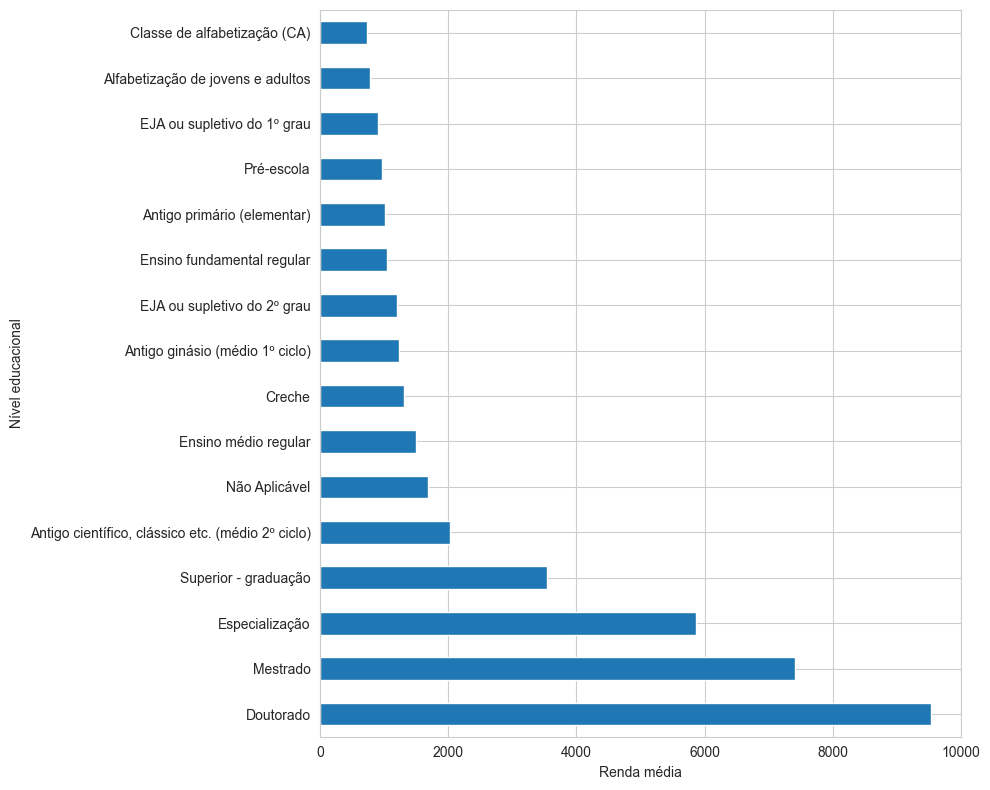

In [74]:
plt.figure(figsize=(10, 8))

(
    df.groupby("nivel_educacional")["renda_mensal"]
    .mean()
    .sort_values(ascending=False)
    .plot.barh()
)

plt.xlabel("Renda média")
plt.ylabel("Nível educacional")
plt.tight_layout()
plt.show()

Com o objetivo de analisar a relação entre escolaridade e rendimento, foi calculada a renda média dos indivíduos para cada nível educacional presente na base de dados. Essa análise permite identificar diferenças salariais entre os grupos e verificar se níveis mais elevados de instrução estão associados a maiores rendimentos.

Os resultados evidenciam uma tendência crescente da renda média conforme aumenta o nível educacional. Os menores valores são observados entre indivíduos com níveis de escolaridade mais baixos, como classe de alfabetização, alfabetização de jovens e adultos e ensino fundamental, cujas rendas médias situam-se próximas de R$700,00 a R$1.000,00.

À medida que o nível de instrução se eleva, observa-se um aumento progressivo nos rendimentos. Indivíduos com ensino médio regular apresentam renda média de aproximadamente R$1.500,00, enquanto aqueles com formação superior em nível de graduação possuem renda média superior a R$3.500,00.

As maiores médias salariais são encontradas entre indivíduos com pós-graduação. Pessoas com especialização apresentam renda média em torno de R$5.865,00, enquanto os rendimentos médios alcançam aproximadamente R$7.409,00 para indivíduos com mestrado e R$9.530,00 para aqueles com doutorado.

De maneira geral, os resultados indicam uma associação positiva entre escolaridade e rendimento, sugerindo que níveis mais elevados de formação estão relacionados a maiores ganhos financeiros. Esse comportamento é consistente com diversos estudos sobre o mercado de trabalho, que apontam a educação como um dos principais fatores associados às diferenças de rendimento entre os indivíduos.

Embora a escolaridade exerça influência importante sobre a renda, é importante destacar que outros fatores, como experiência profissional, ocupação, setor de atividade e características do mercado de trabalho, também contribuem para explicar as diferenças observadas entre os rendimentos.

#### Horas trabalhadas por semana

In [75]:
df_trabalhou = df[df["trabalhou_ou_estagiou"] == "Sim"]

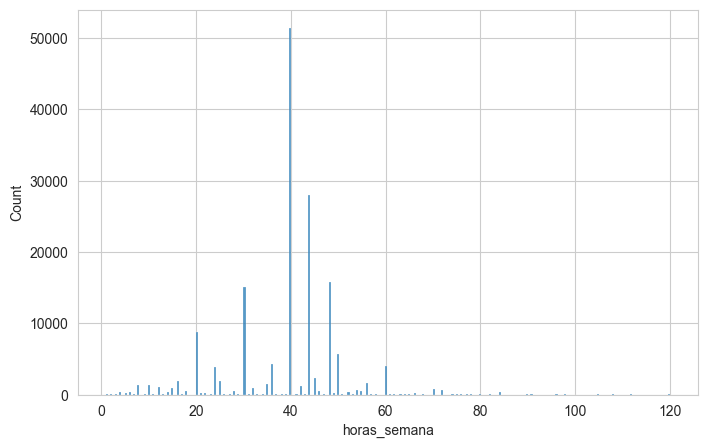

In [76]:
sns.histplot(df_trabalhou["horas_semana"])
plt.show()

In [77]:
df_trabalhou["horas_semana"].describe()

count    162235.000000
mean         38.905273
std          11.735903
min           1.000000
25%          32.000000
50%          40.000000
75%          44.000000
max         120.000000
Name: horas_semana, dtype: float64

Para a análise da jornada semanal de trabalho, foram considerados apenas os indivíduos que declararam ter exercido alguma atividade remunerada. A partir desse subconjunto, foram calculadas estatísticas descritivas e construída uma representação gráfica da distribuição das horas trabalhadas por semana.

Observa-se que a jornada semanal média é de aproximadamente 39 horas, enquanto a mediana corresponde a 40 horas. Os quartis indicam que 25% dos trabalhadores exercem atividades por até 32 horas semanais e que 75% trabalham até 44 horas por semana. Os valores observados variam entre 1 e 120 horas semanais, evidenciando a existência de jornadas bastante distintas entre os indivíduos analisados.

O histograma revela uma forte concentração em torno das jornadas de 40 e 44 horas semanais, que correspondem às cargas horárias mais comuns no mercado de trabalho brasileiro. Também são observadas concentrações em outras faixas de horas, como 20, 30 e 48 horas semanais, refletindo a diversidade de ocupações e regimes de trabalho existentes.

Embora a maior parte dos indivíduos esteja concentrada em jornadas próximas ao padrão tradicional de trabalho, observa-se a presença de trabalhadores com cargas horárias significativamente menores ou maiores, indicando a existência de situações de trabalho parcial e de jornadas extensas.

De maneira geral, os resultados sugerem que a jornada semanal típica dos indivíduos ocupados situa-se em torno de 40 horas, sendo essa uma das características mais marcantes da distribuição observada na base de dados.

#### Relação entre horas trabalhadas e renda

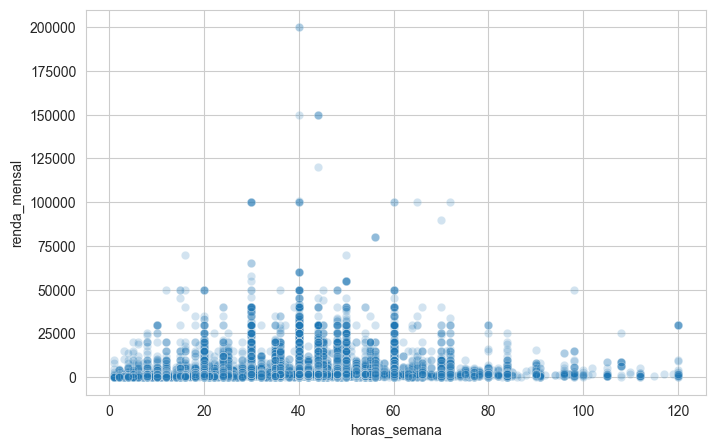

In [78]:
sns.scatterplot(
    data=df_trabalhou,
    x="horas_semana",
    y="renda_mensal",
    alpha=0.2
)
plt.show()

Analisando a relação entre a quantidade de horas trabalhadas por semana e o rendimento bruto mensal dos indivíduos que declararam exercer alguma atividade remunerada, observa-se uma elevada concentração de indivíduos em jornadas próximas de 40 horas semanais, o que está alinhado com a carga horária padrão observada no mercado de trabalho brasileiro. Também há concentrações secundárias em jornadas de 30, 44, 60 e 70 horas semanais, sugerindo a existência de regimes de trabalho relativamente padronizados. Em termos de rendimento, a maior parte das observações encontra-se em faixas salariais mais baixas, especialmente abaixo de R$10.000 mensais, evidenciando uma distribuição fortemente assimétrica à direita. Essa característica é reforçada pela presença de poucos indivíduos com rendimentos substancialmente superiores à média, alcançando valores próximos ou superiores a R$100.000 mensais.

A dispersão dos pontos indica que não existe uma relação linear forte entre as variáveis. Embora seja possível observar uma leve tendência de aumento dos rendimentos à medida que a carga horária cresce, essa associação é relativamente fraca, corroborando o gráfico de calor visto anteriormente. Para praticamente todas as faixas de horas trabalhadas, há ampla variabilidade nos rendimentos observados. Por exemplo, indivíduos que trabalham aproximadamente 40 horas por semana apresentam rendimentos que variam desde valores próximos ao salário mínimo até níveis extremamente elevados. Esse comportamento sugere que fatores adicionais, como escolaridade, ocupação, setor econômico, experiência profissional, localização geográfica e posição hierárquica, provavelmente exercem influência mais significativa sobre a renda do que apenas a quantidade de horas trabalhadas.

Outro aspecto relevante é a presença de valores extremos. Alguns indivíduos apresentam rendimentos muito elevados em jornadas próximas de 40 a 70 horas semanais, destacando-se claramente do restante da distribuição. Esses casos podem representar profissionais altamente qualificados, empresários, executivos ou situações específicas de remuneração. Embora sejam poucos em número, esses valores influenciam significativamente a escala do eixo vertical e dificultam a visualização detalhada da região onde se concentra a maioria das observações. Isso reforça a evidência de assimetria na distribuição dos rendimentos, característica frequentemente observada em pesquisas de renda e trabalho.

Também é possível notar a existência de indivíduos com jornadas muito extensas, superiores a 80 ou até 100 horas semanais. Entretanto, mesmo nesses casos, não se observa um aumento proporcional dos rendimentos. Há trabalhadores com cargas horárias extremamente elevadas recebendo rendimentos relativamente modestos, enquanto outros com jornadas próximas à média apresentam remunerações substancialmente superiores. Esse padrão sugere que a relação entre tempo de trabalho e renda é heterogênea e depende de características estruturais do mercado de trabalho.

#### Carteira assinada

In [79]:
df["carteira_assinada"] = df["carteira_assinada"].map({
    1: "Sim",
    2: "Não",
    999: "Não Aplicável"
})

In [80]:
df["carteira_assinada"].value_counts(dropna=False)

carteira_assinada
Não Aplicável    427849
Sim               54740
Não               48013
Name: count, dtype: int64

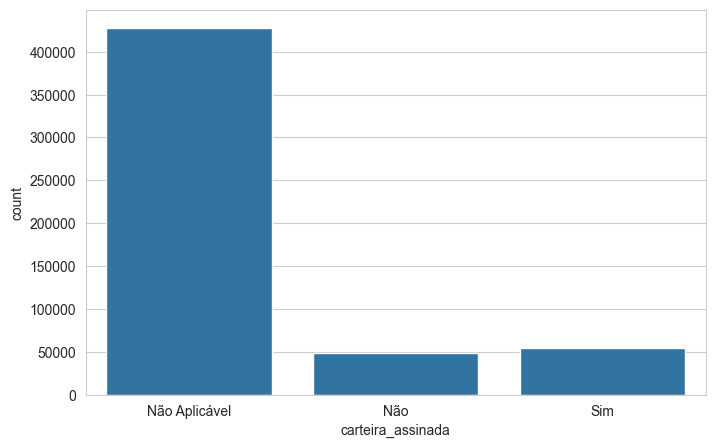

In [81]:
sns.countplot(
    data=df,
    x="carteira_assinada"
)
plt.show()

A variável referente à existência de carteira de trabalho assinada foi convertida dos códigos numéricos da PNAD Contínua para categorias textuais, permitindo uma interpretação mais clara dos resultados. Os casos em que a informação não era aplicável ao indivíduo foram agrupados na categoria "Não Aplicável".

Os resultados mostram que 54.740 indivíduos declararam possuir carteira assinada, enquanto 48.013 afirmaram não possuir esse tipo de vínculo formal. Além disso, 427.849 registros foram classificados como "Não Aplicável", correspondendo principalmente a indivíduos que não se encontravam em ocupações nas quais essa característica pudesse ser observada.

Considerando apenas os indivíduos para os quais a informação é pertinente, observa-se uma distribuição relativamente equilibrada entre trabalhadores com e sem carteira assinada, com uma ligeira predominância daqueles que possuem vínculo formal. Esse resultado evidencia a coexistência de formas formais e informais de inserção no mercado de trabalho.

#### Procurou emprego

In [82]:
df["procurou_emprego"] = df["procurou_emprego"].map({
    1: "Sim",
    2: "Não",
    999: "Não Aplicável"
})

In [83]:
df["procurou_emprego"].value_counts(dropna=False)

procurou_emprego
Não Aplicável    283452
Não              215786
Sim               31364
Name: count, dtype: int64

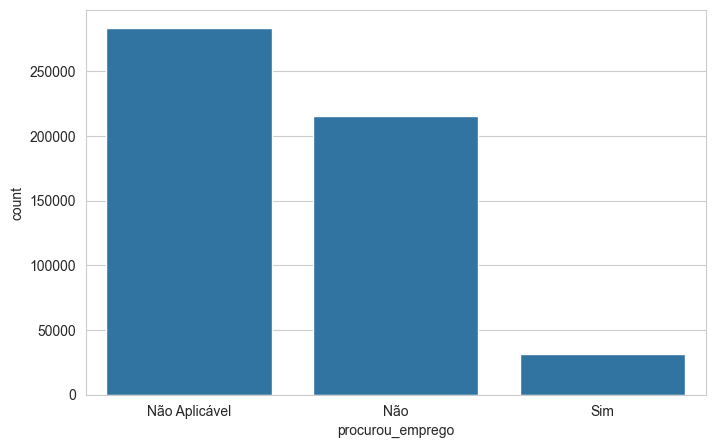

In [84]:
sns.countplot(
    data=df,
    x="procurou_emprego"
)
plt.show()

A variável referente à procura por emprego foi convertida dos códigos numéricos da PNAD Contínua para categorias textuais, permitindo uma interpretação mais intuitiva dos resultados. Os registros em que a pergunta não se aplicava ao indivíduo foram agrupados na categoria "Não Aplicável".

Os resultados mostram que 31.364 indivíduos declararam ter tomado alguma providência para conseguir trabalho ou iniciar um negócio próprio, enquanto 215.786 afirmaram não ter realizado qualquer ação nesse sentido durante o período de referência da pesquisa. Além disso, 283.452 registros foram classificados como "Não Aplicável", correspondendo a indivíduos para os quais essa questão não era pertinente.

Considerando apenas os indivíduos aos quais a pergunta se aplicava, observa-se que a maioria não estava em busca de uma nova ocupação, enquanto uma parcela menor declarou estar procurando emprego ou oportunidades de geração de renda. Esse resultado sugere que grande parte da população analisada encontrava-se em uma situação de relativa estabilidade em relação à inserção no mercado de trabalho ou fora da força de trabalho.

A análise dessa variável é importante para compreender a dinâmica do mercado de trabalho e identificar a parcela da população que se encontrava em busca de ocupação. Em conjunto com as demais variáveis da base, essa informação permite investigar aspectos relacionados ao desemprego, à participação na força de trabalho e às condições de inserção ocupacional dos indivíduos.